# Stage 5: Model selection

This notebook reads the saved cross-validation results and chooses a model using PR-AUC first. It does not refit models or change the results file.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_PATH = PROJECT_ROOT / 'reports' / 'model_comparison.csv'
results = pd.read_csv(RESULTS_PATH)

print(f'Loaded {len(results)} model results from {RESULTS_PATH}')
print('The CSV is only read; this notebook does not write it.')

Loaded 11 model results from /Users/leshakamadara/bank-LM-prediction/reports/model_comparison.csv
The CSV is only read; this notebook does not write it.


## Models sorted by cross-validation PR-AUC

In [2]:
# The primary metric is PR-AUC because the subscribed class is the minority class.
summary = results.assign(
    pr_auc_gap=results['train_pr_auc_mean'] - results['pr_auc_mean']
).sort_values('pr_auc_mean', ascending=False)

display_columns = [
    'name',
    'pr_auc_mean', 'pr_auc_std',
    'roc_auc_mean', 'roc_auc_std',
    'f1_mean', 'f1_std',
    'precision_mean', 'precision_std',
    'recall_mean', 'recall_std',
    'pr_auc_gap', 'fit_time_mean',
]
display(summary[display_columns].round(4))

,name,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,pr_auc_gap,fit_time_mean
3,HistGradientBoosting-tuned,0.4489,0.0112,0.7978,0.0009,0.4463,0.0073,0.3474,0.0101,0.6244,0.0070,0.0707,1.3572
0,HistGradientBoosting,0.4402,0.0095,0.7951,0.0028,0.4459,0.0099,0.3508,0.0120,0.6122,0.0067,0.0822,7.8491
2,Random forest-tuned,0.4375,0.0139,0.7878,0.0039,0.4534,0.0042,0.3717,0.0070,0.5814,0.0102,0.2633,46.3631
10,Random forest,0.4113,0.0153,0.7770,0.0042,0.4245,0.0209,0.4770,0.0167,0.3827,0.0242,0.5887,1.3001
1,Decision tree-tuned,0.4029,0.0133,0.7567,0.0083,0.3601,0.0057,0.2461,0.0047,0.6717,0.0171,0.0873,0.4644
5,KNeighbors-tuned,0.3887,0.0107,0.7546,0.0013,0.2376,0.0119,0.6717,0.0300,0.1444,0.0079,0.6113,0.0548
9,Decision tree depth 6 leaf 50,0.3472,0.0078,0.7490,0.0023,0.3923,0.0085,0.3010,0.0156,0.5663,0.0255,0.0186,0.1286
4,KNeighbors,0.3355,0.0117,0.7291,0.0055,0.2564,0.0113,0.6075,0.0290,0.1626,0.0080,0.1157,0.0638
7,Decision tree gini,0.1764,0.0075,0.6089,0.0091,0.3089,0.0156,0.3077,0.0135,0.3103,0.0187,0.8236,0.2432
8,Decision tree entropy,0.1754,0.0077,0.6091,0.0086,0.3081,0.0153,0.3018,0.0174,0.3148,0.0135,0.8246,0.2620


## Cross-validation PR-AUC with uncertainty

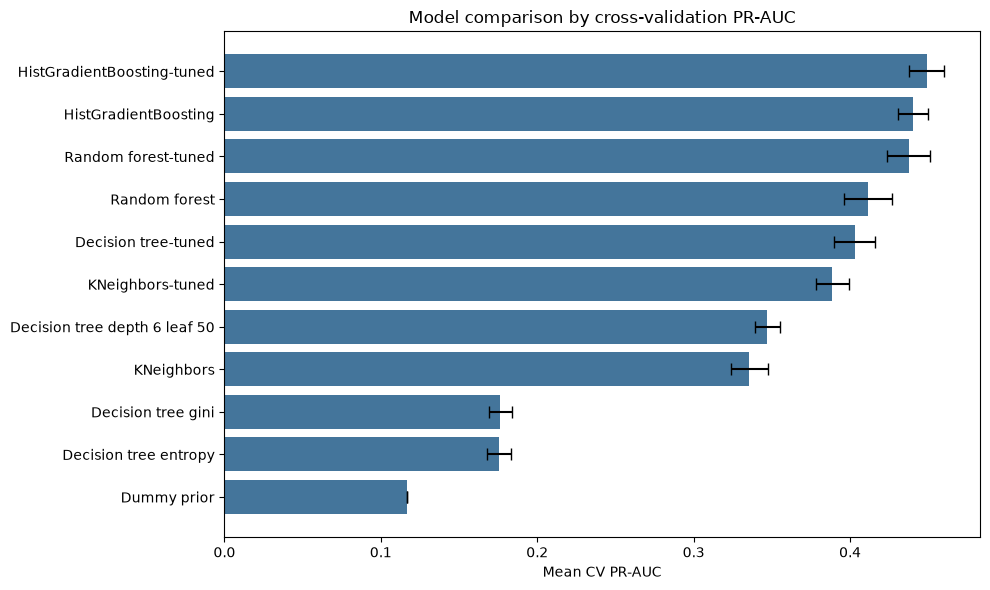

In [3]:
# Error bars show the standard deviation across the five validation folds.
plot_data = summary.sort_values('pr_auc_mean')
plt.figure(figsize=(10, 6))
plt.barh(
    plot_data['name'],
    plot_data['pr_auc_mean'],
    xerr=plot_data['pr_auc_std'],
    color='#2f6690',
    alpha=0.9,
    capsize=4,
)
plt.xlabel('Mean CV PR-AUC')
plt.ylabel('')
plt.title('Model comparison by cross-validation PR-AUC')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

## Ranking and close results

Rank models by mean CV PR-AUC, but do not overstate small differences. A pair is flagged below when the absolute difference between their mean PR-AUC values is smaller than the larger of their fold standard deviations. Such a pair is close enough that the simpler, faster, or easier-to-explain model may be preferable.

In [4]:
# Print the ranking and identify pairs whose difference is smaller than one standard deviation.
for rank, (_, row) in enumerate(summary.iterrows(), start=1):
    print(f'{rank}. {row["name"]}: PR-AUC {row["pr_auc_mean"]:.4f} +/- {row["pr_auc_std"]:.4f}')

close_pairs = []
for left_index in range(len(summary)):
    for right_index in range(left_index + 1, len(summary)):
        left = summary.iloc[left_index]
        right = summary.iloc[right_index]
        difference = abs(left['pr_auc_mean'] - right['pr_auc_mean'])
        one_std = max(left['pr_auc_std'], right['pr_auc_std'])
        if difference < one_std:
            close_pairs.append({
                'model_a': left['name'],
                'model_b': right['name'],
                'mean_difference': difference,
                'larger_std': one_std,
            })

close_pairs = pd.DataFrame(close_pairs).sort_values('mean_difference')
if close_pairs.empty:
    print('No pair has a mean PR-AUC difference smaller than one standard deviation.')
else:
    print('Pairs whose difference is smaller than one standard deviation:')
    display(close_pairs.head(10).round(4))

print('Selection rule: start with the highest PR-AUC, then consider uncertainty, the PR-AUC gap, fit time, and explainability before finalising the model.')

1. HistGradientBoosting-tuned: PR-AUC 0.4489 +/- 0.0112
2. HistGradientBoosting: PR-AUC 0.4402 +/- 0.0095
3. Random forest-tuned: PR-AUC 0.4375 +/- 0.0139
4. Random forest: PR-AUC 0.4113 +/- 0.0153
5. Decision tree-tuned: PR-AUC 0.4029 +/- 0.0133
6. KNeighbors-tuned: PR-AUC 0.3887 +/- 0.0107
7. Decision tree depth 6 leaf 50: PR-AUC 0.3472 +/- 0.0078
8. KNeighbors: PR-AUC 0.3355 +/- 0.0117
9. Decision tree gini: PR-AUC 0.1764 +/- 0.0075
10. Decision tree entropy: PR-AUC 0.1754 +/- 0.0077
11. Dummy prior: PR-AUC 0.1170 +/- 0.0001
Pairs whose difference is smaller than one standard deviation:


,model_a,model_b,mean_difference,larger_std
5,Decision tree gini,Decision tree entropy,0.0010,0.0077
2,HistGradientBoosting,Random forest-tuned,0.0027,0.0139
3,Random forest,Decision tree-tuned,0.0085,0.0153
0,HistGradientBoosting-tuned,HistGradientBoosting,0.0087,0.0112
1,HistGradientBoosting-tuned,Random forest-tuned,0.0114,0.0139
4,Decision tree depth 6 leaf 50,KNeighbors,0.0117,0.0117


Selection rule: start with the highest PR-AUC, then consider uncertainty, the PR-AUC gap, fit time, and explainability before finalising the model.


## Decision

The first-ranked model by mean CV PR-AUC is the leading candidate. The standard-deviation comparison prevents treating a tiny numerical difference as a meaningful improvement. A large train-versus-CV PR-AUC gap is a warning sign for overfitting, while fit time and explainability matter for a model that must be demonstrated and served.